# Regional Pacific marine heatwaves

Regional gridded analysis of marine heatwaves (MHWs) across the tropical and subtropical Pacific, with the Pacific Island EEZ boundaries overlaid. Unlike an MHW analysis of a spatially averaged series, events are detected independently at every ocean grid cell before the regional maps and EEZ summaries are produced.

```{glue:figure} mhw_regional_days
:scale: 75%
:align: center
```

**Figure. Mean annual marine-heatwave days across the Pacific.** Values are derived from daily NOAA OISST and the Hobday et al. (2016) event definition.

In [1]:
# CIndRA notebook display standard
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.dpi': 100,
    'savefig.dpi': 300,
})

In [2]:
from calendar import monthrange
from pathlib import Path
import shutil
import sys
import time
from urllib.error import HTTPError, URLError
from urllib.parse import urlencode
from urllib.request import Request, urlopen

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats
from tqdm.auto import tqdm

try:
    from myst_nb import glue
except ImportError:
    def glue(name, value, display=False): return value

root_candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
repo_root = next((p for p in root_candidates if (p / 'functions/marineHeatWaves.py').is_file()), None)
if repo_root is None:
    raise FileNotFoundError('Could not locate the CIndRA repository root.')
sys.path.insert(0, str(repo_root / 'functions'))
import marineHeatWaves as mhw
from data_downloaders import download_oni_index

## 1. Method and references

At each grid cell, an MHW is an exceedance of the seasonally varying 90th-percentile SST threshold lasting at least five days. Events separated by gaps of two days or fewer are joined. The climatology is fixed at 1983–2012. Annual event count, MHW days, duration and maximum intensity are derived from the events; linear trends use ordinary least squares.

The calculation uses Eric C. J. Oliver's [`marineHeatWaves`](https://github.com/ecjoliver/marineHeatWaves) implementation, downloaded from commit [`d7292bf`](https://github.com/ecjoliver/marineHeatWaves/tree/d7292bf08ade0af213fa760b0d7e4adfe5f52894). The local copy has only the `np.NaN` → `np.nan` NumPy-2 compatibility update.

Daily SST comes from [NOAA OISST v2.1](https://psl.noaa.gov/data/gridded/data.noaa.oisst.v2.highres.html), provided on a global 0.25° grid from September 1981 onward. To make a regional notebook tractable, NOAA's NetCDF Subset Service returns only the Pacific domain at a configurable spatial stride.

- Hobday, A. J. et al. (2016), *Progress in Oceanography*, 141, 227–238. [doi:10.1016/j.pocean.2015.12.014](https://doi.org/10.1016/j.pocean.2015.12.014)
- Hobday, A. J. et al. (2018), *Oceanography*, 31(2), 162–173. [doi:10.5670/oceanog.2018.205](https://doi.org/10.5670/oceanog.2018.205)
- Huang, B. et al. (2021), *Journal of Climate*, 34, 2923–2939. [doi:10.1175/JCLI-D-20-0166.1](https://doi.org/10.1175/JCLI-D-20-0166.1)

## 2. Configuration

In [3]:
data_dir = repo_root / 'data'
cache_dir = data_dir / 'regional' / 'oisst_daily_pacific_2deg'
fig_dir = repo_root / 'matrix_cc' / 'figures'
cache_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

eez_file = data_dir / 'regional/Pacific_EEZs/Pacific_EEZs.shp'
pacific_extent = (125, 245, -35, 35)  # 125°E–115°W, 35°S–35°N
start_year, end_year = 1982, 2025 
requested_climatology_period = [1983, 2012]
climatology_period = [max(start_year, requested_climatology_period[0]),
                      min(end_year, requested_climatology_period[1])]
if climatology_period[1] - climatology_period[0] + 1 < 2:
    raise ValueError('The available period must contain at least two climatology years.')
if climatology_period != requested_climatology_period:
    print(f'WARNING: shortened test climatology: {climatology_period[0]}–{climatology_period[1]}. '          'Use data through 2012 for the definitive 1983–2012 baseline.')

# OISST is 0.25°. A stride of 8 gives a 2° grid (~2,100 cells).
# Set 4 for 1° maps (slower) or 1 for native resolution (very expensive).
horizontal_stride = 8
force_download = False
update_oni = False  # Set True to refresh NOAA ONI; otherwise use the local cache

# Reuse cached map metrics unless configuration/data have changed.
force_recalculate = False
cache_tag = f'{start_year}_{end_year}_clim{climatology_period[0]}_{climatology_period[1]}_stride{horizontal_stride}'
metrics_cache = cache_dir / f'mhw_metrics_{cache_tag}.nc'
eez_summary_file = cache_dir / f'mhw_EEZ_summary_{cache_tag}.csv'

## 3. Download daily Pacific OISST subsets

One compact NetCDF is cached per month. Monthly requests avoid the NOAA proxy timeouts that can occur when the server must generate a full-year subset. Existing files are not downloaded again; failed requests are retried with increasing waits. A `.part` file ensures that an interrupted transfer cannot be mistaken for a complete month.

In [4]:
ncss_template = 'https://psl.noaa.gov/thredds/ncss/grid/Datasets/noaa.oisst.v2.highres/sst.day.mean.{year}.nc'

def ncss_url(year, month):
    west, east, south, north = pacific_extent
    last_day = monthrange(year, month)[1]
    query = urlencode({
        'var': 'sst', 'north': north, 'west': west, 'east': east, 'south': south,
        'horizStride': horizontal_stride,
        'time_start': f'{year}-{month:02d}-01T00:00:00Z',
        'time_end': f'{year}-{month:02d}-{last_day:02d}T23:59:59Z',
        'accept': 'netcdf4',
    })
    return f'{ncss_template.format(year=year)}?{query}'

def download_with_retry(url, target, attempts=6, timeout=180):
    temporary = target.with_suffix(target.suffix + '.part')
    for attempt in range(1, attempts + 1):
        try:
            request = Request(url, headers={'User-Agent': 'CIndRA-MHW/1.0'})
            with urlopen(request, timeout=timeout) as response, temporary.open('wb') as output:
                shutil.copyfileobj(response, output)
            with xr.open_dataset(temporary) as check:
                if 'sst' not in check or check.sizes.get('time', 0) == 0:
                    raise ValueError('The response contains no SST observations.')
            temporary.replace(target)
            return
        except (HTTPError, URLError, TimeoutError, OSError, ValueError) as error:
            if temporary.exists():
                temporary.unlink()
            if attempt == attempts:
                raise RuntimeError(f'NOAA download failed after {attempts} attempts: {url}') from error
            wait_seconds = min(5 * 2 ** (attempt - 1), 60)
            print(f'  attempt {attempt}/{attempts} failed ({error}); retrying in {wait_seconds}s')
            time.sleep(wait_seconds)

monthly_files = []
for year in range(start_year, end_year + 1):
    for month in range(1, 13):
        target = cache_dir / f'oisst_pacific_{year}_{month:02d}_stride{horizontal_stride}.nc'
        monthly_files.append(target)
        if force_download or not target.is_file():
            print(f'Downloading {year}-{month:02d} ...')
            download_with_retry(ncss_url(year, month), target)

print(f'{len(monthly_files)} monthly files ready in {cache_dir}')

528 monthly files ready in /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/CIndRA/data/regional/oisst_daily_pacific_2deg


## 4. Load daily SST and Pacific EEZ boundaries

In [5]:
datasets = [xr.open_dataset(f) for f in monthly_files]
sst = xr.concat([d['sst'] for d in datasets], dim='time').sortby('time')
sst = sst.isel(time=~sst.get_index('time').duplicated())
if float(sst.median(skipna=True)) > 100:
    sst = sst - 273.15
sst = sst.load()

eez = gpd.read_file(eez_file).to_crs(4326)
print(f'{sst.sizes["lon"]} × {sst.sizes["lat"]} grid; {sst.sizes["time"]:,} daily fields')
print(f'{str(sst.time.min().values)[:10]} to {str(sst.time.max().values)[:10]}; {eez.Country.nunique()} EEZs')

61 × 36 grid; 16,071 daily fields
1982-01-01 to 2025-12-31; 29 EEZs


## 5. Grid-cell MHW calculation

The function returns summary fields and the annual MHW-day series needed for trends. Missing cells remain `NaN`. Runtime depends strongly on `horizontal_stride`; the progress bar reports completed latitude rows.

In [6]:
years = np.arange(start_year, end_year + 1)
dates = pd.DatetimeIndex(sst.time.values)
t = np.array([ts.date().toordinal() for ts in dates])

def analyse_cell(temp):
    if np.isfinite(temp).sum() < 0.9 * len(temp):
        return None
    events, clim = mhw.detect(
        t, temp.astype(float), climatologyPeriod=climatology_period,
        pctile=90, windowHalfWidth=5, smoothPercentile=True,
        smoothPercentileWidth=31, minDuration=5,
        joinAcrossGaps=True, maxGap=2, maxPadLength=2,
    )
    annual_days = np.zeros(len(years), dtype=float)
    annual_count = np.zeros(len(years), dtype=float)
    annual_max_category = np.zeros(len(years), dtype=float)
    durations_by_year = [[] for _ in years]
    category_codes = {'Moderate': 1, 'Strong': 2, 'Severe': 3, 'Extreme': 4}
    for i in range(events['n_events']):
        event_dates = dates[events['index_start'][i]:events['index_end'][i] + 1]
        for year, count in pd.Series(event_dates.year).value_counts().items():
            if start_year <= year <= end_year:
                annual_days[year - start_year] += count
        event_year = events['date_start'][i].year
        if start_year <= event_year <= end_year:
            year_index = event_year - start_year
            annual_count[year_index] += 1
            durations_by_year[year_index].append(events['duration'][i])
            event_category = category_codes.get(events['category'][i], 0)
            annual_max_category[year_index] = max(annual_max_category[year_index], event_category)
    annual_median_duration = np.array([
        np.median(values) if values else 0.0 for values in durations_by_year
    ])
    valid_years = np.ones(len(years), dtype=bool)
    if dates.min() > pd.Timestamp(f'{start_year}-01-01'): valid_years[0] = False
    if dates.max() < pd.Timestamp(f'{end_year}-12-31'): valid_years[-1] = False
    slope = stats.linregress(years[valid_years], annual_days[valid_years]).slope * 10
    return (
        annual_days.mean(), slope, annual_count.mean(),
        np.nanmean(events['duration']) if events['n_events'] else 0.0,
        np.nanmean(events['intensity_max']) if events['n_events'] else 0.0,
        annual_days, annual_count, annual_max_category, annual_median_duration,
    )


In [7]:
required_decadal_metrics = {
    'annual_mhw_days', 'annual_event_count',
    'annual_max_category', 'annual_median_duration',
}
cache_is_complete = False
if metrics_cache.is_file() and not force_recalculate:
    cached_metrics = xr.open_dataset(metrics_cache)
    cache_is_complete = required_decadal_metrics.issubset(cached_metrics.data_vars)
    if cache_is_complete:
        metrics = cached_metrics.load()
        cached_metrics.close()
        print(f'Using cached metrics: {metrics_cache}')
    else:
        cached_metrics.close()
        print('The existing cache lacks the decadal-summary metrics; recalculating it once.')

if not cache_is_complete:
    shape2d = (sst.sizes['lat'], sst.sizes['lon'])
    mean_days = np.full(shape2d, np.nan)
    trend_days = np.full(shape2d, np.nan)
    mean_count = np.full(shape2d, np.nan)
    mean_duration = np.full(shape2d, np.nan)
    mean_intensity = np.full(shape2d, np.nan)
    annual_days = np.full((len(years), *shape2d), np.nan)
    annual_count = np.full_like(annual_days, np.nan)
    annual_max_category = np.full_like(annual_days, np.nan)
    annual_median_duration = np.full_like(annual_days, np.nan)

    for j in tqdm(range(sst.sizes['lat']), desc='Latitude rows'):
        for i in range(sst.sizes['lon']):
            result = analyse_cell(sst[:, j, i].values)
            if result is None:
                continue
            (mean_days[j, i], trend_days[j, i], mean_count[j, i],
             mean_duration[j, i], mean_intensity[j, i],
             annual_days[:, j, i], annual_count[:, j, i],
             annual_max_category[:, j, i],
             annual_median_duration[:, j, i]) = result

    coords = {'lat': sst.lat, 'lon': sst.lon}
    metrics = xr.Dataset({
        'mean_mhw_days': (('lat','lon'), mean_days, {'units':'days year-1'}),
        'trend_mhw_days': (('lat','lon'), trend_days, {'units':'days decade-1'}),
        'mean_event_count': (('lat','lon'), mean_count, {'units':'events year-1'}),
        'mean_duration': (('lat','lon'), mean_duration, {'units':'days'}),
        'mean_max_intensity': (('lat','lon'), mean_intensity, {'units':'degC'}),
        'annual_mhw_days': (('year','lat','lon'), annual_days, {'units':'days'}),
        'annual_event_count': (('year','lat','lon'), annual_count, {'units':'events'}),
        'annual_max_category': (('year','lat','lon'), annual_max_category, {'units':'category'}),
        'annual_median_duration': (('year','lat','lon'), annual_median_duration, {'units':'days'}),
    }, coords={**coords, 'year': years})
    metrics.attrs.update(climatology_period=f'{climatology_period[0]}-{climatology_period[1]}', percentile=90, min_duration_days=5,
                         source='NOAA OISST v2.1', spatial_stride=horizontal_stride)
    metrics.to_netcdf(metrics_cache)
    print(f'Saved metrics: {metrics_cache}')


Using cached metrics: /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/CIndRA/data/regional/oisst_daily_pacific_2deg/mhw_metrics_1982_2025_clim1983_2012_stride8.nc


## 6. Regional map helpers

In [8]:
def setup_pacific_map(ax, title):
    ax.set_extent(pacific_extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.88', edgecolor='0.35', linewidth=0.4, zorder=3)
    ax.coastlines(linewidth=0.4, zorder=4)
    eez.boundary.plot(ax=ax, transform=ccrs.PlateCarree(), color='0.2', linewidth=0.6, zorder=5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.35, color='gray', alpha=0.55)
    gl.top_labels = gl.right_labels = False
    ax.set_title(title, fontsize=11)

def plot_metric(field, title, cmap, label, filename, vmin=None, vmax=None):
    projection = ccrs.PlateCarree(central_longitude=180)
    fig, ax = plt.subplots(figsize=(14, 7.5), subplot_kw={'projection': projection})
    im = ax.pcolormesh(field.lon, field.lat, field, transform=ccrs.PlateCarree(),
                       shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    setup_pacific_map(ax, title)
    fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.08, shrink=0.78, aspect=40, label=label)
    fig.savefig(fig_dir / filename, dpi=300, bbox_inches='tight')
    return fig, ax

## 7. Mean annual MHW days

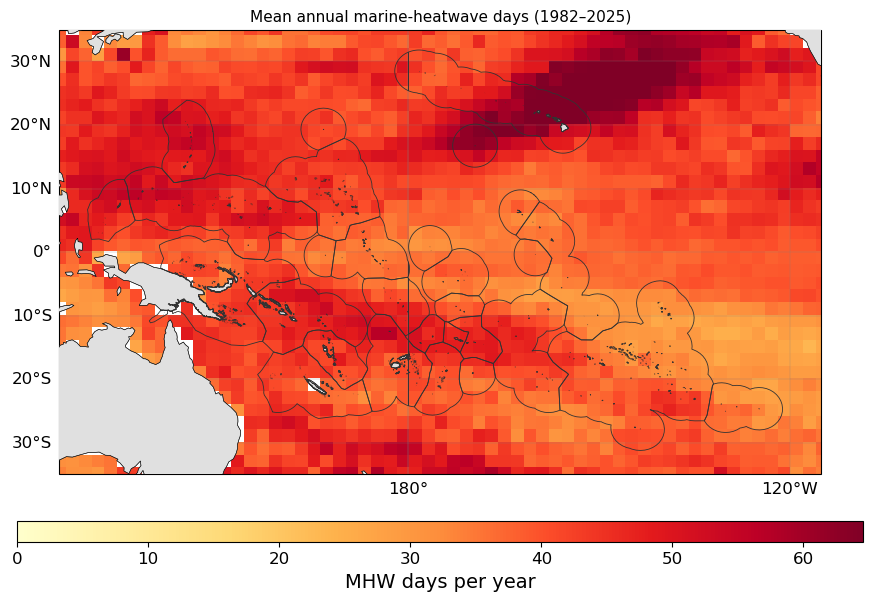

In [9]:
days_max = float(metrics.mean_mhw_days.quantile(0.98))
fig_days, ax_days = plot_metric(
    metrics.mean_mhw_days, f'Mean annual marine-heatwave days ({start_year}–{end_year})',
    'YlOrRd', 'MHW days per year', 'MHW_regional_mean_days.png', vmin=0, vmax=days_max)
glue('mhw_regional_days', fig_days, display=False)
plt.show()

## 8. Trend in annual MHW days

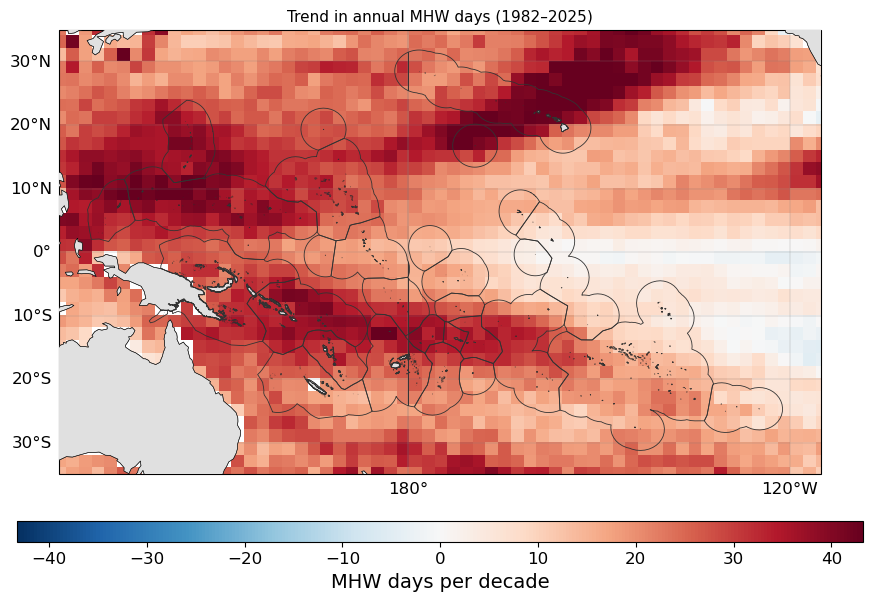

In [10]:
trend_limit = float(abs(metrics.trend_mhw_days).quantile(0.98))
fig_trend, ax_trend = plot_metric(
    metrics.trend_mhw_days, f'Trend in annual MHW days ({start_year}–{end_year})',
    'RdBu_r', 'MHW days per decade', 'MHW_regional_days_trend.png',
    vmin=-trend_limit, vmax=trend_limit)
plt.show()

## 9. Event frequency, duration and intensity

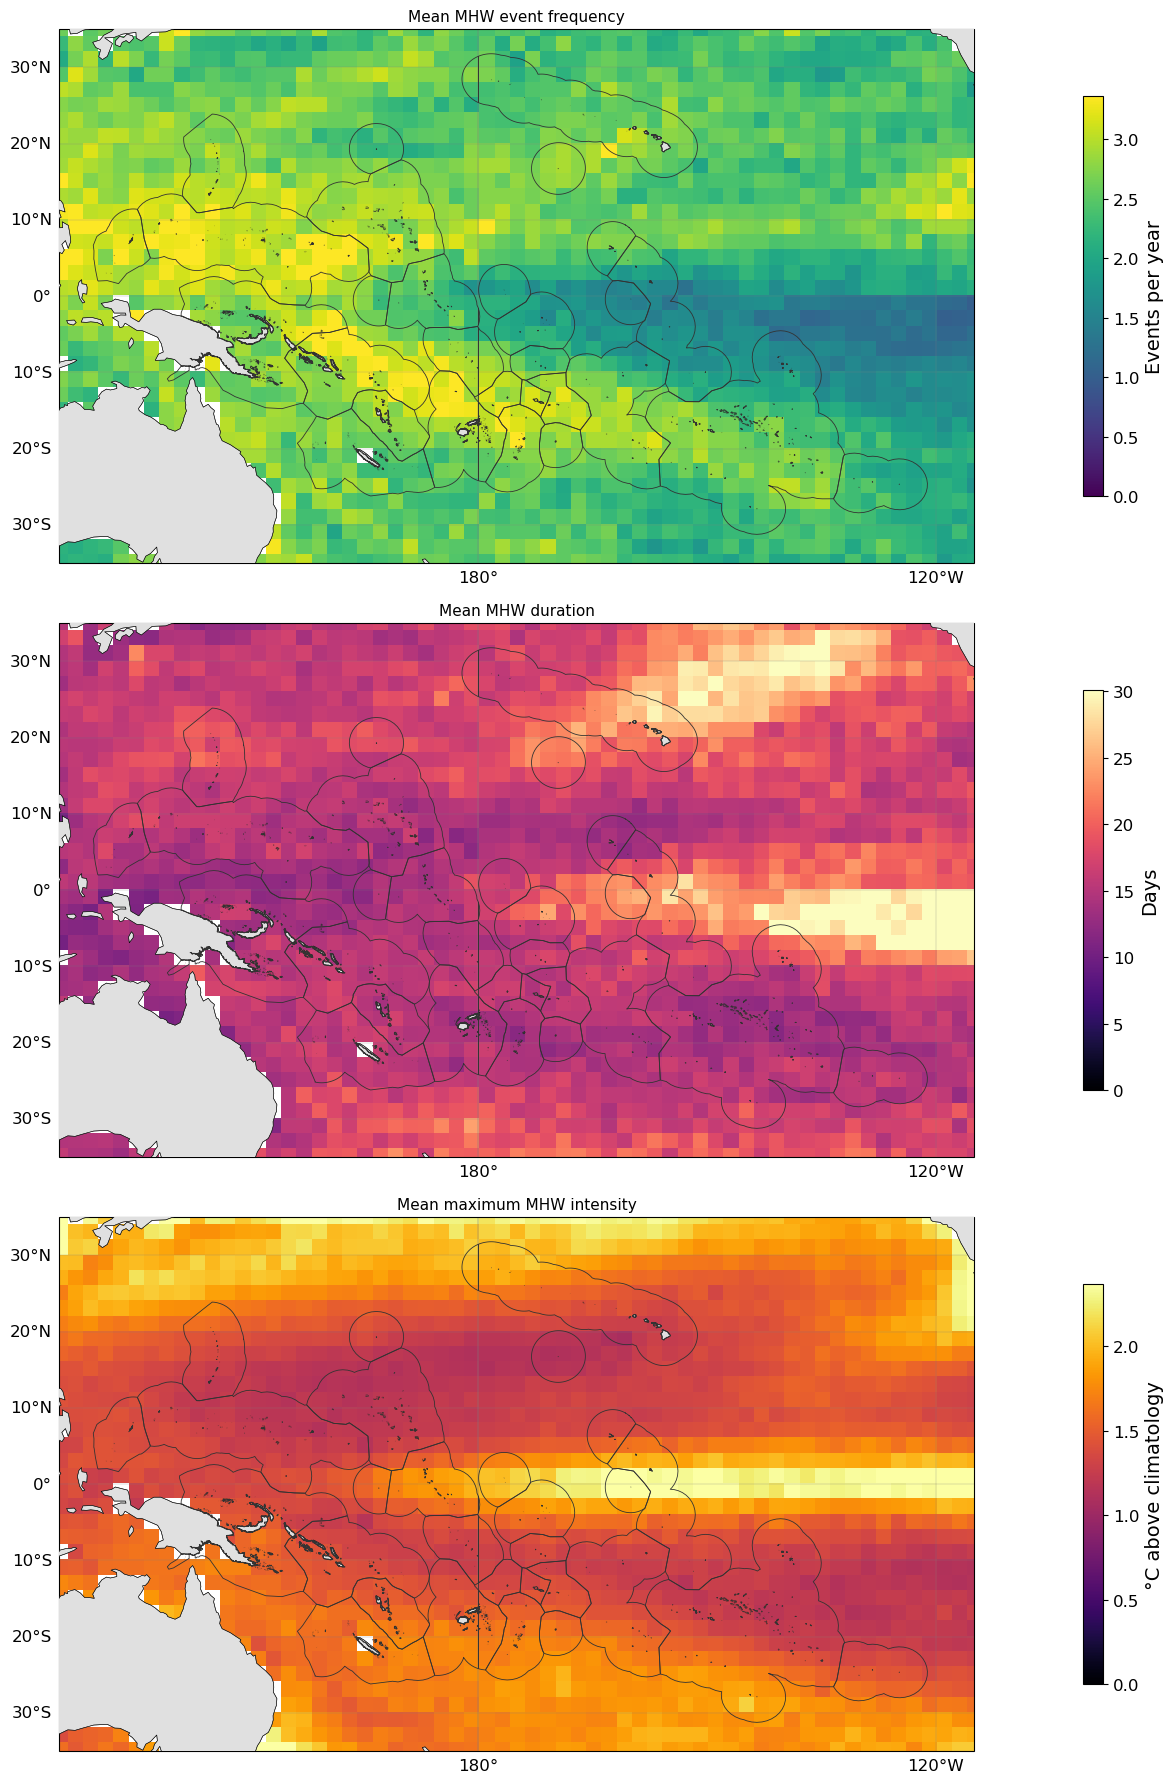

In [11]:
fields = [
    ('mean_event_count', 'Mean MHW event frequency', 'viridis', 'Events per year'),
    ('mean_duration', 'Mean MHW duration', 'magma', 'Days'),
    ('mean_max_intensity', 'Mean maximum MHW intensity', 'inferno', '°C above climatology'),
]
projection = ccrs.PlateCarree(central_longitude=180)
fig, axes = plt.subplots(3, 1, figsize=(14, 18), subplot_kw={'projection': projection})
for ax, (name, title, cmap, label) in zip(axes, fields):
    field = metrics[name]
    vmax = float(field.quantile(0.98))
    im = ax.pcolormesh(field.lon, field.lat, field, transform=ccrs.PlateCarree(),
                       shading='auto', cmap=cmap, vmin=0, vmax=vmax)
    setup_pacific_map(ax, title)
    fig.colorbar(im, ax=ax, orientation='vertical', pad=0.08, shrink=0.75, label=label)
fig.tight_layout()
fig.savefig(fig_dir / 'MHW_regional_frequency_duration_intensity.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Recent five-year MHW-day anomalies

Each panel shows the mean annual MHW days in a five-year block minus the configured climatological-period mean at the same grid cell. The final block can be shorter during a test run.

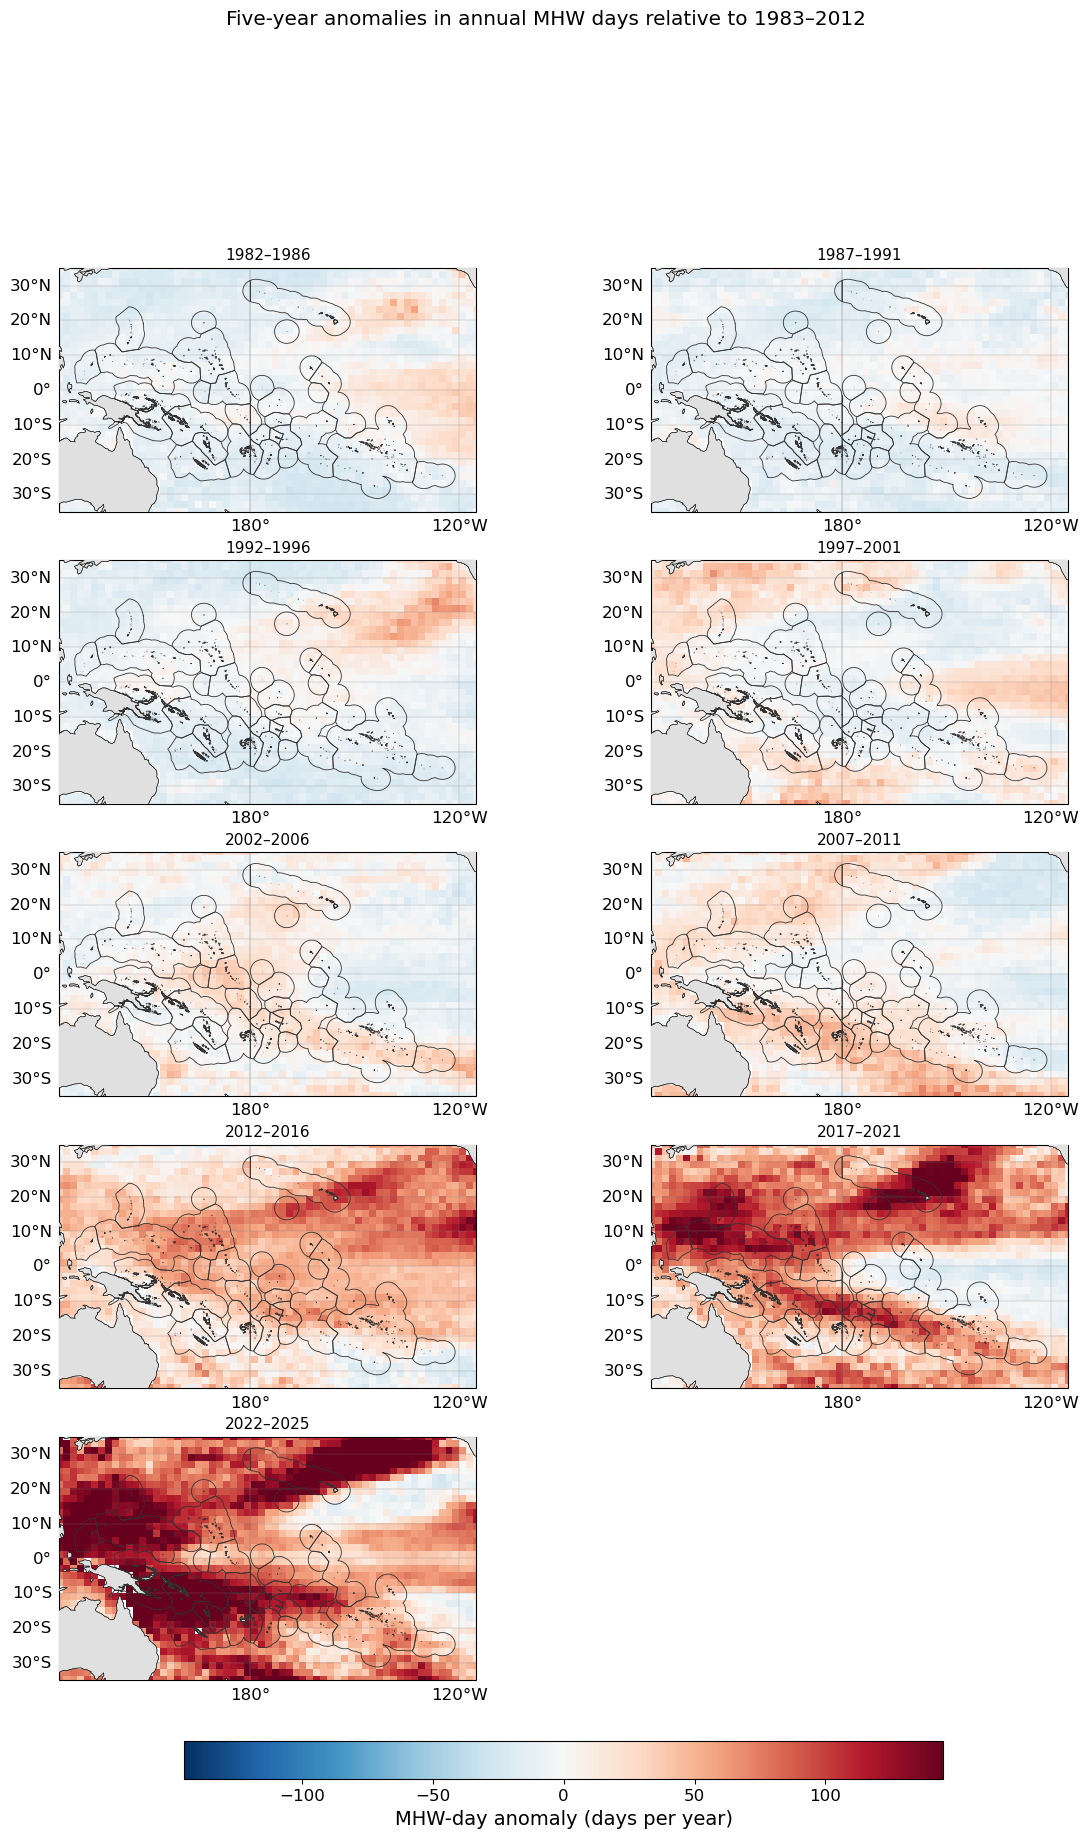

In [12]:
baseline = metrics.annual_mhw_days.sel(year=slice(*climatology_period)).mean('year')
blocks = []
labels = []
for first in range(start_year, end_year + 1, 5):
    last = min(first + 4, end_year)
    blocks.append(metrics.annual_mhw_days.sel(year=slice(first, last)).mean('year') - baseline)
    labels.append(f'{first}–{last}')
block_anomalies = xr.concat(blocks, dim=pd.Index(labels, name='period'))

limit = float(abs(block_anomalies).quantile(0.98))
ncols, nrows = 2, int(np.ceil(len(labels) / 2))
projection = ccrs.PlateCarree(central_longitude=180)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5*nrows), squeeze=False,
                         subplot_kw={'projection': projection})
for ax, label in zip(axes.flat, labels):
    field = block_anomalies.sel(period=label)
    im = ax.pcolormesh(field.lon, field.lat, field, transform=ccrs.PlateCarree(),
                       shading='auto', cmap='RdBu_r', vmin=-limit, vmax=limit)
    setup_pacific_map(ax, label)
for ax in axes.flat[len(labels):]: ax.remove()
fig.suptitle(f'Five-year anomalies in annual MHW days relative to {climatology_period[0]}–{climatology_period[1]}', y=0.995)
fig.colorbar(im, ax=list(axes.flat[:len(labels)]), orientation='horizontal', pad=0.035,
             shrink=0.7, label='MHW-day anomaly (days per year)')
fig.savefig(fig_dir / 'MHW_regional_5year_days_anomalies.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Decadal marine-heatwave summaries

The columns divide the available record into decadal blocks. Rows show the total number
of events, the maximum Hobday severity category, and the median of the annual event-duration medians. Events
are assigned to the year in which they start; the first and last blocks follow the
available data limits.

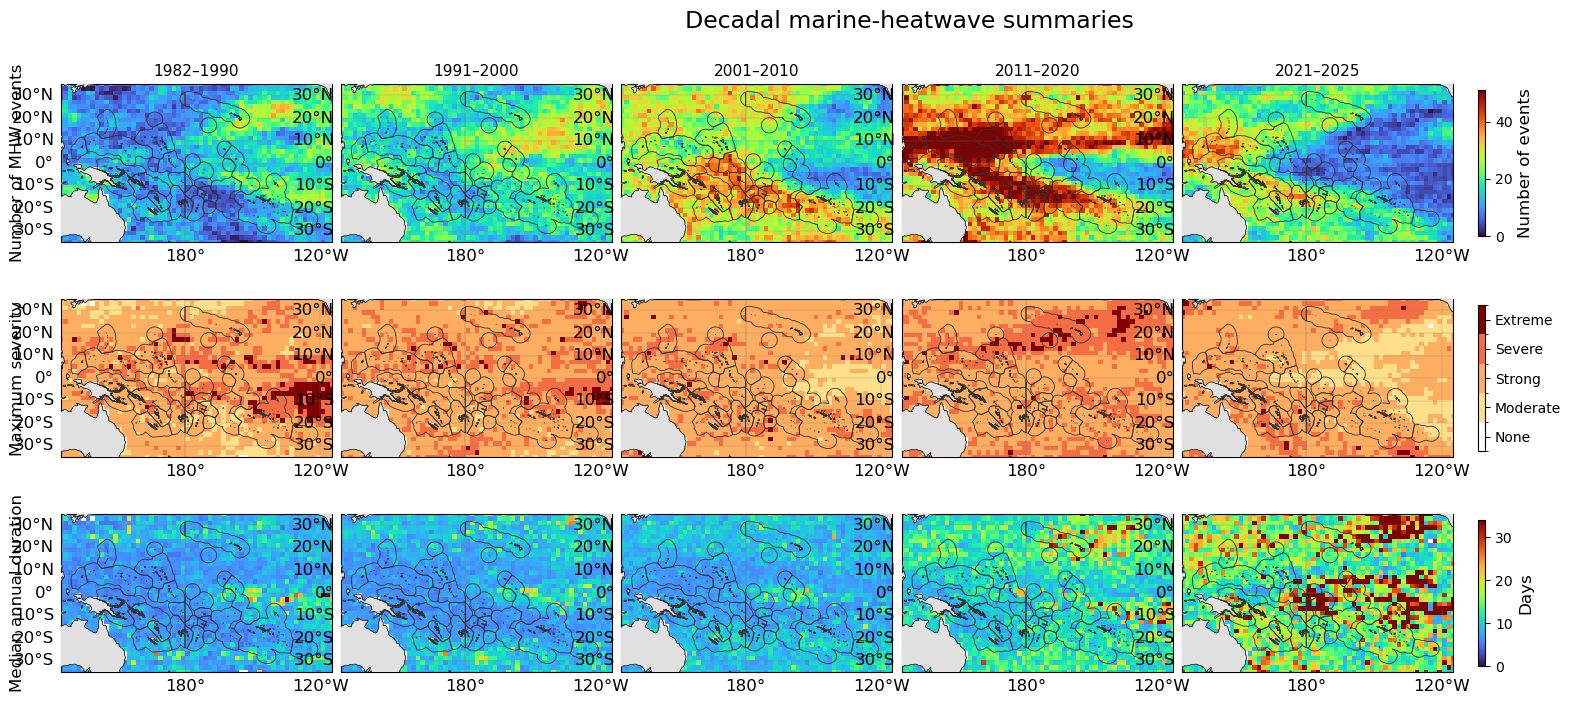

In [13]:
from matplotlib.colors import BoundaryNorm, ListedColormap

period_bounds = [(start_year, min(1990, end_year))]
period_bounds += [(first, min(first + 9, end_year)) for first in range(1991, end_year + 1, 10)]
period_bounds = [(first, last) for first, last in period_bounds if first <= last]
period_labels = [f'{first}–{last}' for first, last in period_bounds]

event_fields = []
severity_fields = []
duration_fields = []
for first, last in period_bounds:
    period = dict(year=slice(first, last))
    event_fields.append(metrics.annual_event_count.sel(**period).sum('year', min_count=1))
    severity_fields.append(metrics.annual_max_category.sel(**period).max('year'))
    durations = metrics.annual_median_duration.sel(**period).where(
        metrics.annual_event_count.sel(**period) > 0
    )
    duration_fields.append(durations.median('year', skipna=True))

event_summary = xr.concat(event_fields, dim=pd.Index(period_labels, name='period'))
severity_summary = xr.concat(severity_fields, dim=pd.Index(period_labels, name='period'))
duration_summary = xr.concat(duration_fields, dim=pd.Index(period_labels, name='period'))

event_vmax = max(1.0, float(event_summary.quantile(0.98)))
duration_vmax = max(1.0, float(duration_summary.quantile(0.98)))
severity_cmap = ListedColormap(['white', '#fee08b', '#fdae61', '#f46d43', '#7f0000'])
severity_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], severity_cmap.N)

fig, axes = plt.subplots(
    3, len(period_labels), figsize=(3.9 * len(period_labels), 7.4),
    squeeze=False, subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
)
row_specs = [
    (event_summary, 'turbo', 0, event_vmax),
    (severity_summary, severity_cmap, None, None),
    (duration_summary, 'turbo', 0, duration_vmax),
]
row_meshes = []
for row_index, (summary, row_cmap, vmin, vmax) in enumerate(row_specs):
    for column_index, period_label in enumerate(period_labels):
        ax = axes[row_index, column_index]
        field_period = summary.sel(period=period_label)
        kwargs = {'norm': severity_norm} if row_index == 1 else {'vmin': vmin, 'vmax': vmax}
        mesh = ax.pcolormesh(
            field_period.lon, field_period.lat, field_period,
            transform=ccrs.PlateCarree(), shading='auto', cmap=row_cmap, **kwargs,
        )
        setup_pacific_map(ax, period_label if row_index == 0 else '')
        if column_index > 0:
            ax.set_ylabel('')
        if column_index == 0:
            ax.text(-0.16, 0.5, ['Number of MHW events', 'Maximum severity', 'Median annual duration'][row_index],
                    transform=ax.transAxes, rotation=90, va='center', ha='center', fontsize=12)
    row_meshes.append(mesh)

fig.subplots_adjust(left=0.065, right=0.92, bottom=0.055, top=0.91, wspace=0.035, hspace=0.06)
colorbar_labels = ['Number of events', '', 'Days']
for row_index, (mesh, label) in enumerate(zip(row_meshes, colorbar_labels)):
    cbar = fig.colorbar(mesh, ax=axes[row_index, :], orientation='vertical', pad=0.015, shrink=0.72)
    if row_index == 1:
        cbar.set_ticks([0, 1, 2, 3, 4])
        cbar.set_ticklabels(['None', 'Moderate', 'Strong', 'Severe', 'Extreme'])
    else:
        cbar.set_label(label, fontsize=12)
    cbar.ax.tick_params(labelsize=10)

fig.suptitle('Decadal marine-heatwave summaries', fontsize=17)
fig.savefig(fig_dir / 'MHW_regional_decadal_summaries.png', dpi=300, bbox_inches='tight')
plt.show()


## 12. EEZ summaries

Grid-cell centres are assigned to each EEZ polygon. The table reports cosine-latitude-weighted spatial means. These summaries describe the mapped grid-cell MHW statistics; small EEZs without a centre at the configured resolution are reported as missing and require a finer `horizontal_stride`.

In [14]:
lon2d, lat2d = np.meshgrid(metrics.lon.values, metrics.lat.values)
lon_for_geometry = np.where(lon2d > 180, lon2d - 360, lon2d)
points = gpd.GeoDataFrame(
    {'row': np.repeat(np.arange(metrics.sizes['lat']), metrics.sizes['lon']),
     'col': np.tile(np.arange(metrics.sizes['lon']), metrics.sizes['lat'])},
    geometry=gpd.points_from_xy(lon_for_geometry.ravel(), lat2d.ravel()), crs=4326)
joined = gpd.sjoin(points, eez[['Country','geometry']], predicate='within', how='inner')

rows = []
for country, group in joined.groupby('Country'):
    jj, ii = group.row.to_numpy(), group.col.to_numpy()
    weights = np.cos(np.deg2rad(metrics.lat.values[jj]))
    row = {'Country': country, 'grid_cells': len(group)}
    for name in ['mean_mhw_days','trend_mhw_days','mean_event_count','mean_duration','mean_max_intensity']:
        values = metrics[name].values[jj, ii]
        valid = np.isfinite(values)
        row[name] = np.average(values[valid], weights=weights[valid]) if valid.any() else np.nan
    rows.append(row)

eez_summary = pd.DataFrame(rows).sort_values('mean_mhw_days', ascending=False).reset_index(drop=True)
eez_summary.to_csv(eez_summary_file, index=False)
eez_summary.round(2)

,Country,grid_cells,mean_mhw_days,trend_mhw_days,mean_event_count,mean_duration,mean_max_intensity
0,Johnston Atoll,9,58.68,38.73,2.83,20.76,1.14
1,Hawaii,53,52.16,31.25,2.55,20.39,1.55
2,Northern Mariana Islands and Guam,21,50.88,36.77,2.85,17.93,1.39
3,Palau,11,49.08,37.05,3.10,15.89,1.41
4,Wallis and Futuna,7,48.47,36.64,3.04,16.00,1.35
5,Solomon Islands,33,47.80,36.67,3.09,15.55,1.38
6,Micronesia,64,47.46,35.82,3.17,15.02,1.28
7,Samoa,3,47.26,34.54,3.08,15.40,1.40
8,American Samoa,8,46.10,32.39,3.03,15.20,1.39
9,Vanuatu,14,43.02,29.50,2.81,15.32,1.57


## 13. Marine heatwaves by ENSO phase

The Oceanic Niño Index (ONI) is classified with the same event rule used elsewhere in this project: **El Niño** requires at least five consecutive monthly ONI values above +0.5 °C, and **La Niña** requires at least five consecutive values below −0.5 °C. Months that do not belong to a qualifying sequence are Neutral.

Because the gridded MHW indicators are stored by calendar year, each calendar year is assigned the qualifying phase present in that year. If both warm and cold qualifying months occur, the phase with more qualifying months is used; a tie is Neutral. This preserves the five-consecutive-month rule while aligning ENSO with `annual_mhw_days.year`.

In [15]:
def detect_enso_events(oni_df):
    """Apply the project's five-consecutive-month ONI threshold rule."""
    result = oni_df.copy()
    result['ONI Mode'] = 'Neutral'
    for column, threshold_mask, label in [
        ('El Nino', result.ONI > 0.5, 'El Nino'),
        ('La Nina', result.ONI < -0.5, 'La Nina'),
    ]:
        result[column] = False
        qualifying_end = threshold_mask.rolling(5, min_periods=5).sum().eq(5)
        for i in np.flatnonzero(qualifying_end.to_numpy()):
            result.iloc[i-4:i+1, result.columns.get_loc(column)] = True
        result.loc[result[column], 'ONI Mode'] = label
    return result

def get_dominant_enso(values):
    nino = (values == 'El Nino').sum()
    nina = (values == 'La Nina').sum()
    return 'El Nino' if nino > nina else ('La Nina' if nina > nino else 'Neutral')

oni_url = 'https://psl.noaa.gov/data/correlation/oni.data'
oni_cache = cache_dir / 'oni_index.pkl'

if update_oni or not oni_cache.is_file():
    try:
        oni = download_oni_index(oni_url)
        oni.to_pickle(oni_cache)
        print(f'Updated ONI cache: {oni_cache}')
    except Exception:
        if not oni_cache.is_file():
            raise
        print('NOAA ONI update failed; using the existing local cache.')
        oni = pd.read_pickle(oni_cache)
else:
    oni = pd.read_pickle(oni_cache)

enso_monthly = detect_enso_events(oni)
enso_yearly = enso_monthly.groupby(enso_monthly.index.year)['ONI Mode'].agg(get_dominant_enso)
enso_yearly.index.name = 'year'
enso_yearly = enso_yearly.reindex(years, fill_value='Neutral')

phase_order = ['La Nina', 'Neutral', 'El Nino']
phase_labels = {'La Nina': 'La Niña', 'Neutral': 'Neutral', 'El Nino': 'El Niño'}
phase_colors = {'La Nina': '#2166ac', 'Neutral': '#969696', 'El Nino': '#d73027'}

enso_counts = enso_yearly.value_counts().reindex(phase_order, fill_value=0).rename('years').to_frame()
enso_counts.index = [phase_labels[p] for p in enso_counts.index]
enso_counts

,years
La Niña,19
Neutral,5
El Niño,20


### Regional mean annual MHW days by ENSO phase

The first figure summarizes the Pacific-wide area-weighted MHW-day series. Bars are coloured by the annual ENSO classification. The table reports phase sample sizes and the mean and standard deviation of the regional index.

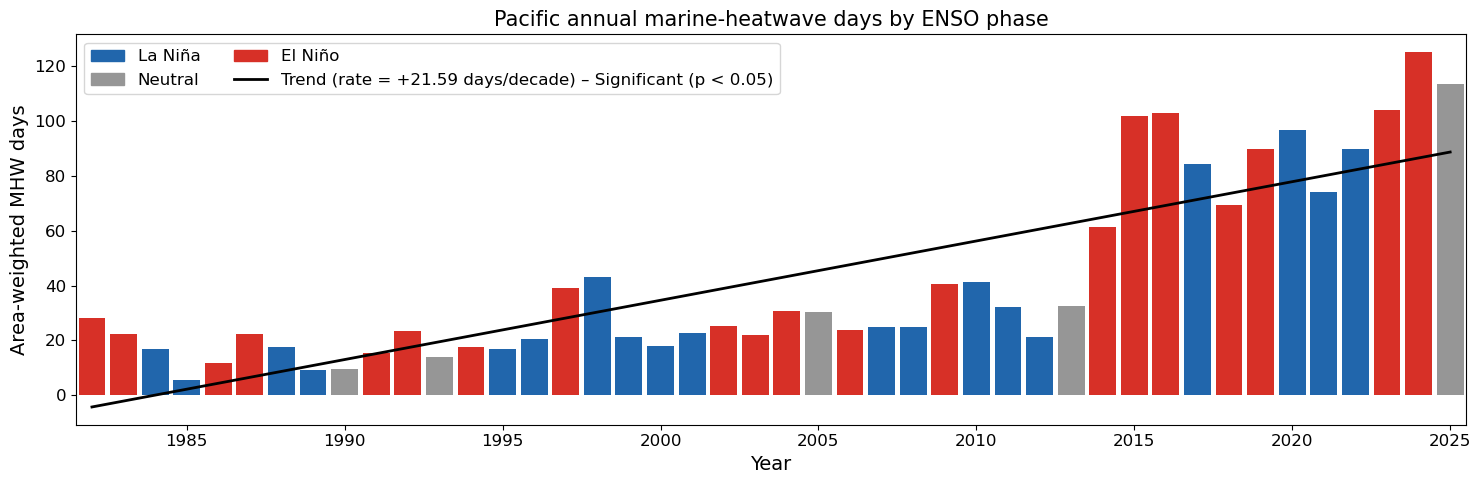

,count,mean,std
La Niña,19,35.78,28.47
Neutral,5,40.00,42.29
El Niño,20,48.84,36.38


In [16]:
area_weights = np.cos(np.deg2rad(metrics.lat))
regional_annual_days = metrics.annual_mhw_days.weighted(area_weights).mean(('lat', 'lon')).to_series()
regional_enso = pd.DataFrame({'mhw_days': regional_annual_days}).join(enso_yearly.rename('ENSO'))

fig, ax = plt.subplots(figsize=(15, 5))
bar_colors = regional_enso.ENSO.map(phase_colors)
ax.bar(regional_enso.index, regional_enso.mhw_days, color=bar_colors, width=0.85)
valid = regional_enso.mhw_days.notna()
trend_result = stats.linregress(regional_enso.index[valid], regional_enso.loc[valid, 'mhw_days'])
significant = trend_result.pvalue < 0.05
trend_style = '-' if significant else '--'
significance_text = 'Significant (p < 0.05)' if significant else 'Not significant (p ≥ 0.05)'
trend_line, = ax.plot(
    regional_enso.index[valid],
    trend_result.intercept + trend_result.slope * regional_enso.index[valid],
    color='black', lw=2, linestyle=trend_style,
    label=f'Trend (rate = {trend_result.slope * 10:+.2f} days/decade) – {significance_text}',
)
handles = [plt.Rectangle((0, 0), 1, 1, color=phase_colors[p], label=phase_labels[p]) for p in phase_order]
handles.append(trend_line)
ax.legend(handles=handles, ncol=2, fontsize=12)
ax.set(xlabel='Year', ylabel='Area-weighted MHW days',
       title='Pacific annual marine-heatwave days by ENSO phase')
ax.set_xlim(years.min() - 0.5, years.max() + 0.5)
fig.tight_layout()
fig.savefig(fig_dir / 'MHW_regional_annual_days_ENSO.png', dpi=300, bbox_inches='tight')
plt.show()

regional_enso_summary = regional_enso.groupby('ENSO').mhw_days.agg(['count', 'mean', 'std']).reindex(phase_order)
regional_enso_summary.index = [phase_labels[p] for p in regional_enso_summary.index]
regional_enso_summary.round(2)

### Anomaly maps by ENSO phase

Each panel shows the phase composite minus the grid-cell mean over the complete analysis period. The common diverging scale is symmetric around zero.

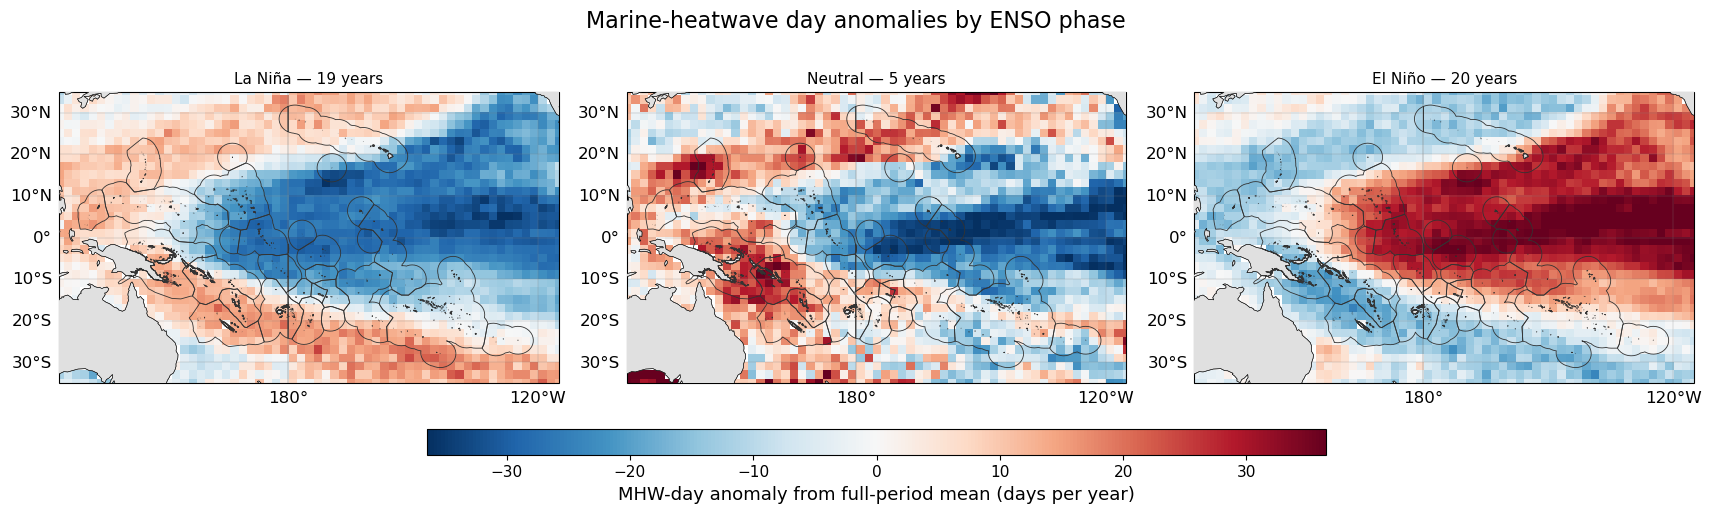

In [17]:
phase_order = ['La Nina', 'Neutral', 'El Nino']
phase_labels = {'La Nina': 'La Niña', 'Neutral': 'Neutral', 'El Nino': 'El Niño'}
phase_fields = []
phase_counts = {}

for phase in phase_order:
    years_phase = enso_yearly.index[enso_yearly.eq(phase)].to_numpy(dtype=int)
    years_phase = years_phase[np.isin(years_phase, metrics.year.values)]
    phase_counts[phase] = len(years_phase)
    phase_fields.append(metrics.annual_mhw_days.sel(year=years_phase).mean('year'))

phase_means = xr.concat(phase_fields, dim=pd.Index(phase_order, name='ENSO'))
full_period_mean = metrics.annual_mhw_days.mean('year')
phase_anomalies = phase_means - full_period_mean

finite_anomalies = phase_anomalies.values[np.isfinite(phase_anomalies.values)]
limit = float(np.nanpercentile(np.abs(finite_anomalies), 98))
fig, axes = plt.subplots(
    1, 3, figsize=(17, 5),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
    constrained_layout=True,
)
for ax, phase in zip(axes, phase_order):
    setup_pacific_map(ax, f"{phase_labels[phase]} — {phase_counts[phase]} years")
    field_phase = phase_anomalies.sel(ENSO=phase)
    mesh = ax.pcolormesh(
        field_phase.lon, field_phase.lat, field_phase,
        transform=ccrs.PlateCarree(), cmap='RdBu_r',
        vmin=-limit, vmax=limit, shading='auto',
    )

fig.suptitle('Marine-heatwave day anomalies by ENSO phase', fontsize=16)
cb = fig.colorbar(mesh, ax=axes, orientation='horizontal', pad=0.06, shrink=0.55, aspect=35)
cb.set_label('MHW-day anomaly from full-period mean (days per year)', fontsize=13)
cb.ax.tick_params(labelsize=11)
fig.savefig(fig_dir / 'MHW_regional_ENSO_anomalies.png', dpi=180, bbox_inches='tight')
plt.show()


### ENSO-conditioned EEZ summary

For each ZEE and ENSO phase, the table gives the spatially weighted mean of the phase-specific MHW-day map and its anomaly from the complete-period mean. It uses the same grid-cell-to-ZEE assignment created above.

In [18]:
enso_eez_rows = []
for phase in phase_order:
    phase_field = phase_means.sel(ENSO=phase)
    anomaly_field = phase_field - full_period_mean
    for country, group in joined.groupby('Country'):
        jj = group.row.to_numpy(dtype=int)
        ii = group.col.to_numpy(dtype=int)
        weights = np.cos(np.deg2rad(metrics.lat.values[jj]))
        values = phase_field.values[jj, ii]
        anomalies = anomaly_field.values[jj, ii]
        valid = np.isfinite(values) & np.isfinite(weights)
        valid_anomaly = np.isfinite(anomalies) & np.isfinite(weights)
        enso_eez_rows.append({
            'Country': country,
            'ENSO_phase': phase_labels[phase],
            'n_years': phase_counts[phase],
            'grid_cells': len(group),
            'mean_mhw_days_per_year': np.average(values[valid], weights=weights[valid]) if valid.any() else np.nan,
            'anomaly_from_full_period_mean_days': np.average(anomalies[valid_anomaly], weights=weights[valid_anomaly]) if valid_anomaly.any() else np.nan,
        })

enso_eez_summary = pd.DataFrame(enso_eez_rows)
enso_eez_summary.to_csv(cache_dir / 'regional_MHW_ENSO_EEZ_summary.csv', index=False)
enso_eez_summary.head(12)


,Country,ENSO_phase,n_years,grid_cells,mean_mhw_days_per_year,anomaly_from_full_period_mean_days
0,American Samoa,La Niña,19,8,33.763130,-12.339609
1,Cook Islands,La Niña,19,42,32.166163,-7.989619
2,Fiji,La Niña,19,28,51.496959,9.049399
3,French Polynesia,La Niña,19,103,34.788518,-1.104273
4,Hawaii,La Niña,19,53,52.472481,0.311700
5,Howland Island and Baker Island,La Niña,19,9,6.139737,-27.065012
6,Jarvis Island,La Niña,19,7,7.029804,-28.953800
7,Johnston Atoll,La Niña,19,9,38.159548,-20.518822
8,Kiribati,La Niña,19,21,7.981579,-27.728364
9,Line Group,La Niña,19,35,10.528038,-22.465647


### ENSO interpretation notes

- The five-consecutive-month ONI rule identifies established ENSO episodes; an isolated monthly threshold crossing remains Neutral.
- Phase composites should always be read with their sample sizes, especially in short test periods such as 1982–1989.
- These are descriptive composites. Differences between phases are not automatically statistically significant, and adjacent years/grid cells are not independent.
- ENSO can affect MHW occurrence differently across the western, central and eastern Pacific; the regional maps are therefore more informative than the Pacific-wide mean alone.

## Interpretation and computational notes

- Detection is performed independently at each ocean grid cell; this differs from detecting events in a Pacific-mean or EEZ-mean SST series.
- Spatial coarsening is controlled by `horizontal_stride`. A stride of 8 samples the native 0.25° grid every eight cells (2°) and is intended for an exploratory regional product. Publication-quality coastal and small-island results should be rerun at stride 4 or finer.
- The definitive event baseline is 1983–2012. For short test runs it is automatically truncated to the available years and a warning is shown; those test results are not directly comparable with the definitive analysis.
- OISST is a gridded surface product. Local reef exposure may differ because of depth, currents, coastal geometry and unresolved processes.
- EEZ boundaries are visual and analytical overlays; they do not imply endorsement of boundary claims.

## Interpretation and reproducibility notes

- Regional aggregates can hide local differences among stations, grid cells and EEZs.
- Gridded SST resolution, data gaps and the selected climatological baseline affect anomalies, extremes and marine-heatwave metrics.
- Linear trends are descriptive unless the notebook explicitly accounts for temporal autocorrelation and other statistical assumptions.
- Confirm the printed source, analysis period, reference period and output paths before using figures or tables in reporting.